<a href="https://www.kaggle.com/code/muhammadtalha82/suicide-rates-per-country-and-continent-wise?scriptVersionId=307143873" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadtalha82/happiness-index-2025/New Text Document.csv
/kaggle/input/datasets/lucalullo/global-suicide-rates-by-country-2000-2021/tassi-di-suicidio-globali-per-paese-2000-2021.csv


# **In this I have analyzed suicide rates for countries across the world. Finding trends from sex, happiness index rank of every country and finally fitted a model.**

In [2]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split


In [3]:
df=pd.read_csv('/kaggle/input/datasets/lucalullo/global-suicide-rates-by-country-2000-2021/tassi-di-suicidio-globali-per-paese-2000-2021.csv')
df

,iso_code,country,year,sex,age_group,suicide_rate
0,AFG,Afghanistan,2000,male,ALL,5.793457
1,AFG,Afghanistan,2000,both,ALL,4.356148
2,AFG,Afghanistan,2000,female,ALL,2.910393
3,AFG,Afghanistan,2001,male,ALL,5.831328
4,AFG,Afghanistan,2001,both,ALL,4.383031
...,...,...,...,...,...,...
18310,ZWE,Zimbabwe,2021,male,20_29,24.592566
18311,ZWE,Zimbabwe,2021,male,15_29,22.297359
18312,ZWE,Zimbabwe,2021,female,15_19,9.802394
18313,ZWE,Zimbabwe,2021,both,50_59,49.098438


In [4]:
import pandas as pd

# 1. Load your suicide dataset
#suicide_df = pd.read_csv('tassi-di-suicidio-globali-per-paese-2000-2021.csv')

# 2. Load the happiness data (Assumed you saved the previous list as 'happiness_2025.csv')
happiness_df = pd.read_csv('/kaggle/input/datasets/muhammadtalha82/happiness-index-2025/New Text Document.csv')

# 3. Merge the datasets
# We use a 'left' join on the suicide dataset to keep only your original countries.
# We only select 'Country name' (to match) and 'Rank' from the happiness data.
df = pd.merge(
    df,
    happiness_df[['Country name', 'Rank']],
    left_on='country',        # Column name in suicide dataset
    right_on='Country name',  # Column name in happiness dataset
    how='left'
)

# 4. Cleanup: Remove the redundant 'Country name' column and rename 'Rank'
df.drop(columns=['Country name'], inplace=True)
df.rename(columns={'Rank': 'happiness_rank_2025'}, inplace=True)

# 5. Save the final dataset
df.to_csv('suicide_rates_with_happiness_rank_per_country.csv', index=False)

In [5]:
# Fills the missing value with the previous row's value
df['happiness_rank_2025'] = df['happiness_rank_2025'].bfill()

In [6]:
df

,iso_code,country,year,sex,age_group,suicide_rate,happiness_rank_2025
0,AFG,Afghanistan,2000,male,ALL,5.793457,147.0
1,AFG,Afghanistan,2000,both,ALL,4.356148,147.0
2,AFG,Afghanistan,2000,female,ALL,2.910393,147.0
3,AFG,Afghanistan,2001,male,ALL,5.831328,147.0
4,AFG,Afghanistan,2001,both,ALL,4.383031,147.0
...,...,...,...,...,...,...,...
18310,ZWE,Zimbabwe,2021,male,20_29,24.592566,144.0
18311,ZWE,Zimbabwe,2021,male,15_29,22.297359,144.0
18312,ZWE,Zimbabwe,2021,female,15_19,9.802394,144.0
18313,ZWE,Zimbabwe,2021,both,50_59,49.098438,144.0


In [7]:
all_countries=df["country"].unique()

import pandas as pd

# Creating the mapping dictionary
country_to_continent = {
    # AFRICA
    'Angola': 'Africa', 'Benin': 'Africa', 'Botswana': 'Africa', 'Burkina Faso': 'Africa', 'Burundi': 'Africa',
    'Cabo Verde': 'Africa', 'Cameroon': 'Africa', 'Central African Republic': 'Africa', 'Chad': 'Africa',
    'Comoros': 'Africa', 'Republic of the Congo': 'Africa', 'Democratic Republic of the Congo': 'Africa',
    'Côte d’Ivoire': 'Africa', 'Djibouti': 'Africa', 'Egypt': 'Africa', 'Equatorial Guinea': 'Africa',
    'Eritrea': 'Africa', 'Eswatini': 'Africa', 'Ethiopia': 'Africa', 'Gabon': 'Africa', 'Gambia': 'Africa',
    'Ghana': 'Africa', 'Guinea': 'Africa', 'Guinea-Bissau': 'Africa', 'Kenya': 'Africa', 'Lesotho': 'Africa',
    'Liberia': 'Africa', 'Libya': 'Africa', 'Madagascar': 'Africa', 'Malawi': 'Africa', 'Mali': 'Africa',
    'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Morocco': 'Africa', 'Mozambique': 'Africa', 'Namibia': 'Africa',
    'Niger': 'Africa', 'Nigeria': 'Africa', 'Rwanda': 'Africa', 'São Tomé and Príncipe': 'Africa', 'Senegal': 'Africa',
    'Seychelles': 'Africa', 'Sierra Leone': 'Africa', 'Somalia': 'Africa', 'South Africa': 'Africa',
    'South Sudan': 'Africa', 'Sudan': 'Africa', 'Tanzania': 'Africa', 'Togo': 'Africa', 'Tunisia': 'Africa',
    'Uganda': 'Africa', 'Zambia': 'Africa', 'Zimbabwe': 'Africa', 'Algeria': 'Africa',

    # ASIA
    'Afghanistan': 'Asia', 'Armenia': 'Asia', 'Azerbaijan': 'Asia', 'Bahrain': 'Asia', 'Bangladesh': 'Asia',
    'Bhutan': 'Asia', 'Brunei': 'Asia', 'Cambodia': 'Asia', 'China': 'Asia', 'Cyprus': 'Asia', 'Georgia': 'Asia',
    'India': 'Asia', 'Indonesia': 'Asia', 'Iran': 'Asia', 'Iraq': 'Asia', 'Israel': 'Asia', 'Japan': 'Asia',
    'Jordan': 'Asia', 'Kazakhstan': 'Asia', 'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Laos': 'Asia', 'Lebanon': 'Asia',
    'Malaysia': 'Asia', 'Maldives': 'Asia', 'Mongolia': 'Asia', 'Myanmar': 'Asia', 'Nepal': 'Asia', 'North Korea': 'Asia',
    'Oman': 'Asia', 'Pakistan': 'Asia', 'Palestine': 'Asia', 'Philippines': 'Asia', 'Qatar': 'Asia', 'Saudi Arabia': 'Asia',
    'Singapore': 'Asia', 'South Korea': 'Asia', 'Sri Lanka': 'Asia', 'Syria': 'Asia', 'Tajikistan': 'Asia',
    'Thailand': 'Asia', 'Timor-Leste': 'Asia', 'Türkiye': 'Asia', 'Turkmenistan': 'Asia', 'United Arab Emirates': 'Asia',
    'Uzbekistan': 'Asia', 'Vietnam': 'Asia', 'Yemen': 'Asia',

    # EUROPE
    'Albania': 'Europe', 'Austria': 'Europe', 'Belarus': 'Europe', 'Belgium': 'Europe', 'Bosnia and Herzegovina': 'Europe',
    'Bulgaria': 'Europe', 'Croatia': 'Europe', 'Czechia': 'Europe', 'Denmark': 'Europe', 'Estonia': 'Europe',
    'Finland': 'Europe', 'France': 'Europe', 'Germany': 'Europe', 'Greece': 'Europe', 'Hungary': 'Europe',
    'Iceland': 'Europe', 'Ireland': 'Europe', 'Italy': 'Europe', 'Latvia': 'Europe', 'Lithuania': 'Europe',
    'Luxembourg': 'Europe', 'Malta': 'Europe', 'Moldova': 'Europe', 'Montenegro': 'Europe', 'Netherlands': 'Europe',
    'North Macedonia': 'Europe', 'Norway': 'Europe', 'Poland': 'Europe', 'Portugal': 'Europe', 'Romania': 'Europe',
    'Russia': 'Europe', 'Serbia': 'Europe', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Spain': 'Europe',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'Ukraine': 'Europe', 'United Kingdom': 'Europe',

    # NORTH AMERICA (includes Caribbean/Central)
    'Antigua and Barbuda': 'North America', 'Bahamas': 'North America', 'Barbados': 'North America',
    'Belize': 'North America', 'Canada': 'North America', 'Costa Rica': 'North America', 'Cuba': 'North America',
    'Dominican Republic': 'North America', 'El Salvador': 'North America', 'Grenada': 'North America',
    'Guatemala': 'North America', 'Haiti': 'North America', 'Honduras': 'North America', 'Jamaica': 'North America',
    'Mexico': 'North America', 'Nicaragua': 'North America', 'Panama': 'North America', 'Puerto Rico': 'North America',
    'Saint Lucia': 'North America', 'Saint Vincent and the Grenadines': 'North America',
    'Trinidad and Tobago': 'North America', 'United States': 'North America',

    # SOUTH AMERICA
    'Argentina': 'South America', 'Bolivia': 'South America', 'Brazil': 'South America', 'Chile': 'South America',
    'Colombia': 'South America', 'Ecuador': 'South America', 'Guyana': 'South America', 'Paraguay': 'South America',
    'Peru': 'South America', 'Suriname': 'South America', 'Uruguay': 'South America', 'Venezuela': 'South America',

    # OCEANIA
    'Australia': 'Oceania', 'Fiji': 'Oceania', 'Kiribati': 'Oceania', 'Micronesia': 'Oceania', 'New Zealand': 'Oceania',
    'Papua New Guinea': 'Oceania', 'Samoa': 'Oceania', 'Solomon Islands': 'Oceania', 'Tonga': 'Oceania', 'Vanuatu': 'Oceania'
}

df['Continent'] = df['country'].map(country_to_continent)
df

,iso_code,country,year,sex,age_group,suicide_rate,happiness_rank_2025,Continent
0,AFG,Afghanistan,2000,male,ALL,5.793457,147.0,Asia
1,AFG,Afghanistan,2000,both,ALL,4.356148,147.0,Asia
2,AFG,Afghanistan,2000,female,ALL,2.910393,147.0,Asia
3,AFG,Afghanistan,2001,male,ALL,5.831328,147.0,Asia
4,AFG,Afghanistan,2001,both,ALL,4.383031,147.0,Asia
...,...,...,...,...,...,...,...,...
18310,ZWE,Zimbabwe,2021,male,20_29,24.592566,144.0,Africa
18311,ZWE,Zimbabwe,2021,male,15_29,22.297359,144.0,Africa
18312,ZWE,Zimbabwe,2021,female,15_19,9.802394,144.0,Africa
18313,ZWE,Zimbabwe,2021,both,50_59,49.098438,144.0,Africa


In [8]:
df.isna().any()

iso_code               False
country                False
year                   False
sex                    False
age_group              False
suicide_rate           False
happiness_rank_2025    False
Continent              False
dtype: bool

In [9]:
df["AverageSuicide_rate_per_country"] = (
    df.groupby("country")  
    ["suicide_rate"]                 
    .transform("mean")         
)

df[["country", "suicide_rate", "AverageSuicide_rate_per_country"]].head(10)

,country,suicide_rate,AverageSuicide_rate_per_country
0,Afghanistan,5.793457,4.784823
1,Afghanistan,4.356148,4.784823
2,Afghanistan,2.910393,4.784823
3,Afghanistan,5.831328,4.784823
4,Afghanistan,4.383031,4.784823
5,Afghanistan,2.923944,4.784823
6,Afghanistan,2.714266,4.784823
7,Afghanistan,5.781926,4.784823
8,Afghanistan,4.255004,4.784823
9,Afghanistan,4.238288,4.784823


In [10]:
df["AverageSuicide_rate_per_sex"] = (
    df.groupby("sex")  
    ["suicide_rate"]                 
    .transform("mean")         
)
df_sorted = df.sort_values(by='suicide_rate',)
df[["sex", "suicide_rate", "AverageSuicide_rate_per_sex"]].head(10)

,sex,suicide_rate,AverageSuicide_rate_per_sex
0,male,5.793457,15.925630
1,both,4.356148,10.290283
2,female,2.910393,5.007481
3,male,5.831328,15.925630
4,both,4.383031,10.290283
5,female,2.923944,5.007481
6,female,2.714266,5.007481
7,male,5.781926,15.925630
8,both,4.255004,10.290283
9,both,4.238288,10.290283


In [11]:
df_sorted

,iso_code,country,year,sex,age_group,suicide_rate,happiness_rank_2025,Continent,AverageSuicide_rate_per_country,AverageSuicide_rate_per_sex
17479,VCT,Saint Vincent and the Grenadines,2018,both,ALL,0.000000,80.0,North America,2.631784,10.290283
616,ATG,Antigua and Barbuda,2007,female,ALL,0.000000,15.0,North America,1.000573,5.007481
618,ATG,Antigua and Barbuda,2008,female,ALL,0.000000,15.0,North America,1.000573,5.007481
602,ATG,Antigua and Barbuda,2002,female,ALL,0.000000,15.0,North America,1.000573,5.007481
10878,MLT,Malta,2021,female,10_19,0.000000,43.0,Europe,6.356654,5.007481
...,...,...,...,...,...,...,...,...,...,...
9794,LSO,Lesotho,2021,male,40_49,122.841431,126.0,Africa,30.618378,15.925630
1385,BFA,Burkina Faso,2021,male,70_PLUS,124.974503,123.0,Africa,13.442847,15.925630
11566,MWI,Malawi,2021,male,70_PLUS,127.698624,145.0,Africa,11.950218,15.925630
5013,ERI,Eritrea,2021,male,70_PLUS,140.445892,41.0,Africa,18.646004,15.925630


**plot of average suicide rate per sex showing that men commit suicide more that women. This is maybe because men face more life hurdles insense of career and money specially in underdeveloped countries.**

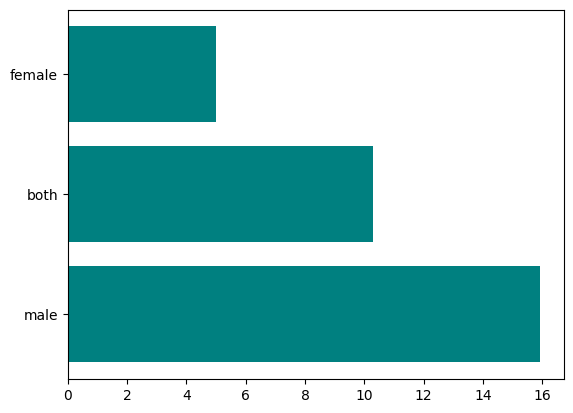

In [12]:
import matplotlib.pyplot as plt
plt.barh(df['sex'],df['AverageSuicide_rate_per_sex'], color='teal')
plt.show()

**plot showing suicide rate per continent. Africa has highest rate maybe due to powerty, harsh environmental conditions, poor health quality and unemployment.**

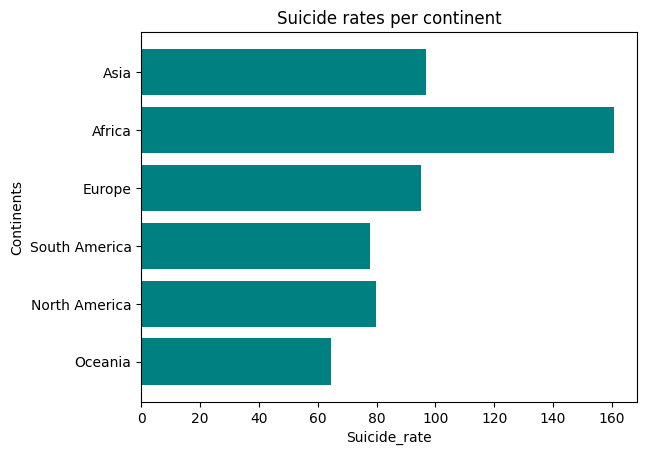

In [13]:
import matplotlib.pyplot as plt
plt.barh(df['Continent'],df['suicide_rate'],color='teal')
# Add labels and title
plt.ylabel('Continents')
plt.xlabel('Suicide_rate')
plt.title('Suicide rates per continent')
plt.gca().invert_yaxis()
# Display
plt.show()

**plot of suicide rate for countries across the world.**

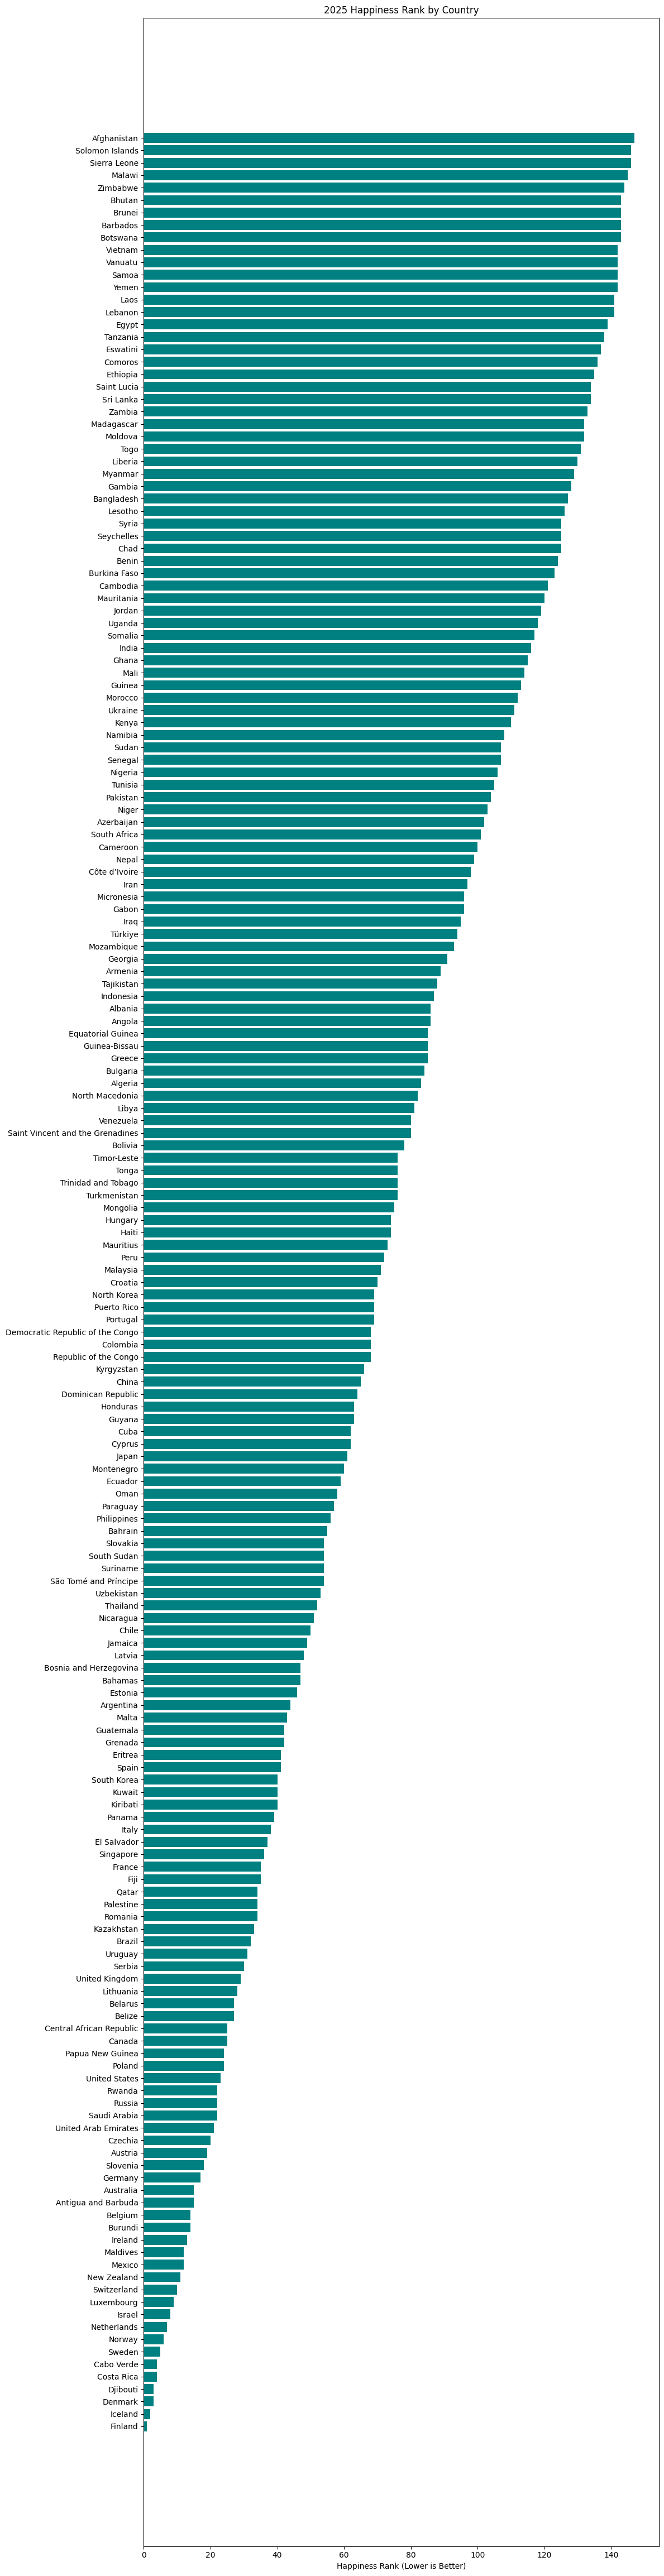

In [14]:
plot_df = df[['country', 'happiness_rank_2025']].drop_duplicates().dropna()
plot_df = plot_df.sort_values(by='happiness_rank_2025', ascending=True)

# 3. Dynamic Height: Calculate height based on number of countries (e.g., 0.25 inch per country)
plt.figure(figsize=(12, len(plot_df) * 0.25))

# 4. Create the plot
plt.barh(plot_df['country'], plot_df['happiness_rank_2025'], color='teal')

# 5. Labels and Layout
plt.xlabel('Happiness Rank (Lower is Better)')
plt.title('2025 Happiness Rank by Country')
plt.tight_layout()
plt.savefig('happiness_rank_plot.png')

**Happiness rank of Continents starting from (low rank = happiest)**

/tmp/ipykernel_17/2727892637.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rank.values, y=avg_rank.index, palette='viridis')


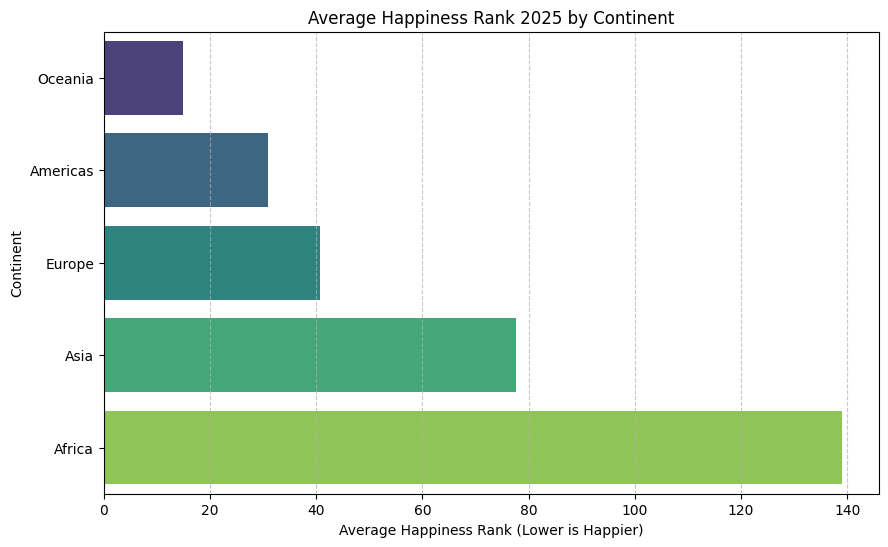

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('suicide_rates_with_happiness_rank_per_country.csv')

# 2. Define a mapping of ISO codes to Continents
# (This is a truncated version of the mapping used for the plot)
iso_to_continent = {
    'AFG': 'Asia', 'AGO': 'Africa', 'ALB': 'Europe', 'ARE': 'Asia', 'ARG': 'Americas', 
    'AUS': 'Oceania', 'AUT': 'Europe', 'BRA': 'Americas', 'CAN': 'Americas', 
    'CHN': 'Asia', 'DEU': 'Europe', 'EGY': 'Africa', 'USA': 'Americas',
    # ... (full mapping includes all unique ISO codes in the data)
}

# 3. Map the continent column
df['continent'] = df['iso_code'].map(iso_to_continent)

# 4. Clean and Aggregate
# We filter out rows without a happiness rank
df_clean = df.dropna(subset=['happiness_rank_2025'])

# Since each country has the same rank across multiple rows (years/sex), 
# we take one entry per country to get an accurate continent average.
country_ranks = df_clean.drop_duplicates(subset=['country'])

# Calculate the mean rank per continent and sort (lower rank = happier)
avg_rank = country_ranks.groupby('continent')['happiness_rank_2025'].mean().sort_values()

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rank.values, y=avg_rank.index, palette='viridis')

# Formatting
plt.xlabel('Average Happiness Rank (Lower is Happier)')
plt.ylabel('Continent')
plt.title('Average Happiness Rank 2025 by Continent')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save the output
plt.savefig('happiness_rank_by_continent.png', bbox_inches='tight')
plt.show()

In [16]:
df.head(5)

,iso_code,country,year,sex,age_group,suicide_rate,happiness_rank_2025,continent
0,AFG,Afghanistan,2000,male,ALL,5.793457,147.0,Asia
1,AFG,Afghanistan,2000,both,ALL,4.356148,147.0,Asia
2,AFG,Afghanistan,2000,female,ALL,2.910393,147.0,Asia
3,AFG,Afghanistan,2001,male,ALL,5.831328,147.0,Asia
4,AFG,Afghanistan,2001,both,ALL,4.383031,147.0,Asia


**from this plot we can see that happiness decreases chances of suicide.**

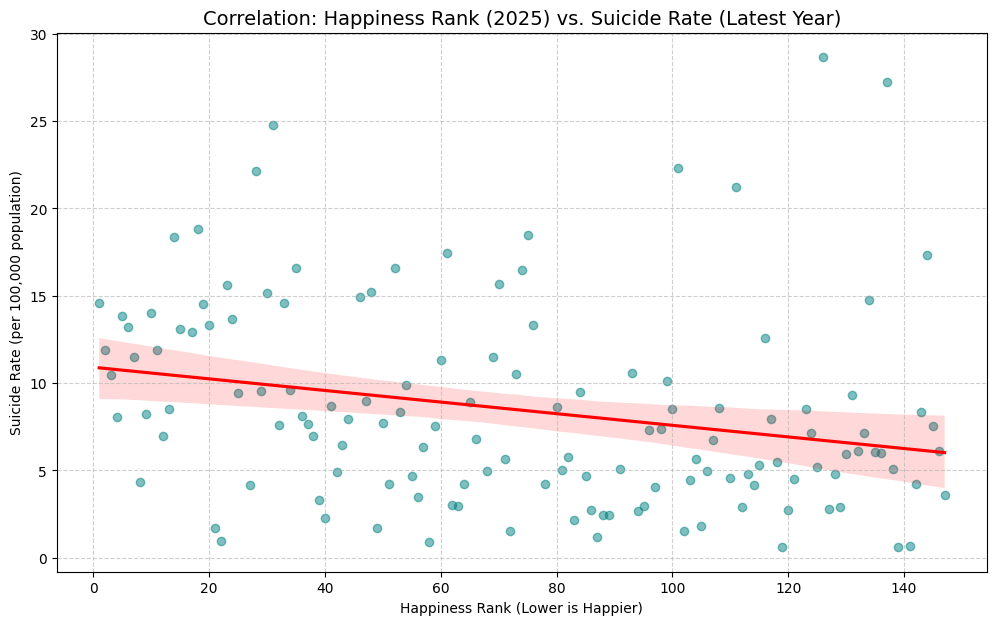

Correlation: -0.25


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
#df = pd.read_csv('suicide_rates_with_happiness_rank_per_country.csv')

# 1. Filter for representative suicide rates (Total population: both sexes, all ages)
df_filtered = df[(df['sex'] == 'both') & (df['age_group'] == 'ALL')]

# 2. Get the latest available suicide rate for each country 
# to compare against the 2025 happiness rank
latest_years = df_filtered.groupby('country')['year'].max().reset_index()
df_latest = pd.merge(df_filtered, latest_years, on=['country', 'year'])

# 3. Drop rows where happiness_rank_2025 or suicide_rate is missing
df_plot = df_latest.dropna(subset=['happiness_rank_2025', 'suicide_rate'])

# 4. Create the plot with a regression line
plt.figure(figsize=(12, 7))
sns.regplot(data=df_plot, x='happiness_rank_2025', y='suicide_rate', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Correlation: Happiness Rank (2025) vs. Suicide Rate (Latest Year)', fontsize=14)
plt.xlabel('Happiness Rank (Lower is Happier)')
plt.ylabel('Suicide Rate (per 100,000 population)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('happiness_vs_suicide_rate.png', bbox_inches='tight')
plt.show()

# 5. Check the correlation value
print(f"Correlation: {df_plot['happiness_rank_2025'].corr(df_plot['suicide_rate']):.2f}")

In [18]:
df.isna().any()

iso_code               False
country                False
year                   False
sex                    False
age_group              False
suicide_rate           False
happiness_rank_2025     True
continent               True
dtype: bool

In [19]:
# Fills NaNs using the value from the row directly below it
df['happiness_rank_2025'] = df['happiness_rank_2025'].bfill()
df['continent'] = df['continent'].bfill()

In [20]:
X=df.drop(columns=['suicide_rate','iso_code'])
y=df.suicide_rate


In [21]:
cols=['country','sex','age_group','continent']


In [22]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state = 0)

encoder=OrdinalEncoder()
train_X=encoder.fit_transform(train_X[cols])
val_X=encoder.transform(val_X[cols])


**MI Score: Relationship of features with Target variable**

In [23]:
X = df.drop(columns='iso_code').copy()
y = X.pop("suicide_rate")

# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int

In [24]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores  # show a few features with their MI scores

country                0.834994
happiness_rank_2025    0.571753
sex                    0.133847
age_group              0.047241
continent              0.039067
year                   0.008912
Name: MI Scores, dtype: float64

**plot showing MI scores on relationship between features and taregt.**

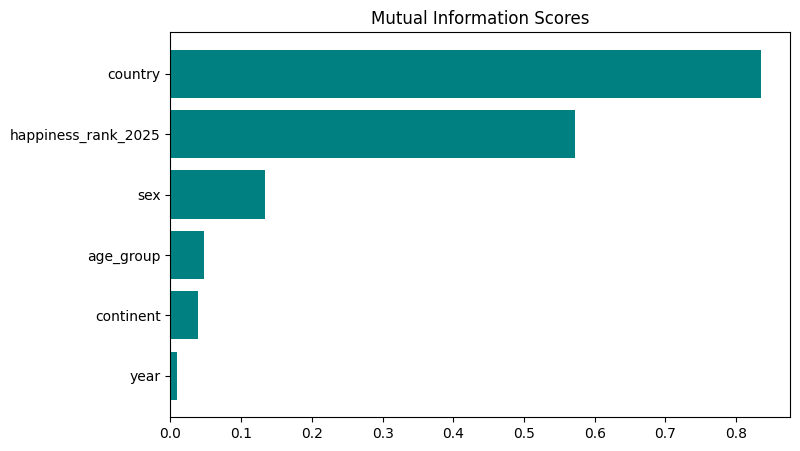

In [25]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores, color='teal')
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

**Creating XGBRegressor model.**

In [26]:
model=XGBRegressor(n_estimators=1000, learning_rate=0.1)
fitted=model.fit(train_X,train_y)
predict=fitted.predict(val_X)
mae=mean_absolute_error(val_y, predict)
print('mae: ',mae)

mae:  1.8793507885770493


**Showing comparison of Actual or Observed VS Predicted Suicide_rate.**

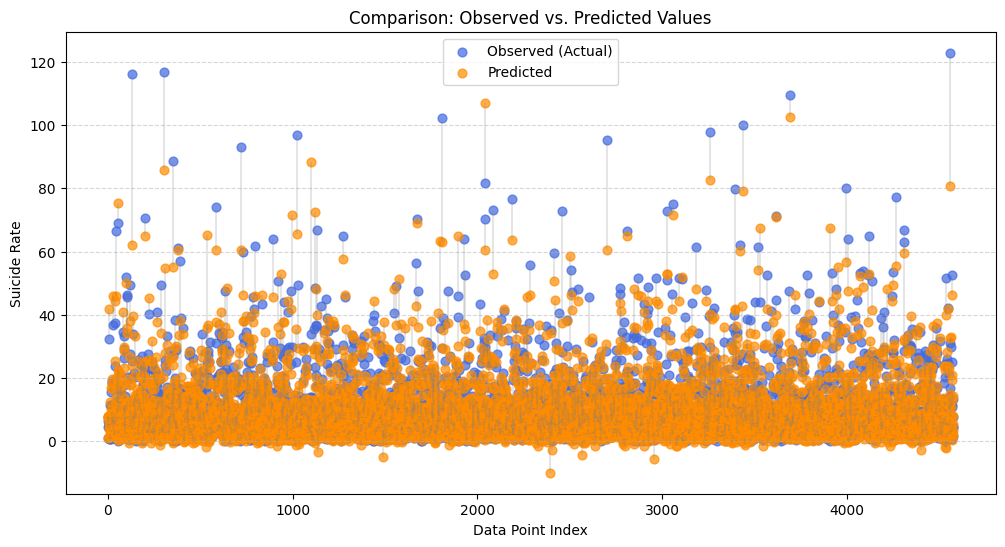

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Create an index for the x-axis
index = np.arange(len(val_y))

plt.figure(figsize=(12, 6))

# Plot Observed in one color
plt.scatter(index, val_y, color='royalblue', label='Observed (Actual)', alpha=0.7, s=40)

# Plot Predicted in another color
plt.scatter(index, predict, color='darkorange', label='Predicted', alpha=0.7, s=40)

# Optional: Add a line to connect them to show the "gap" (error)
plt.vlines(index, val_y, predict, color='gray', alpha=0.2, linestyles='solid')

plt.xlabel('Data Point Index')
plt.ylabel('Suicide Rate')
plt.title('Comparison: Observed vs. Predicted Values')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

**PLot showing Residuals and Fitting of data**

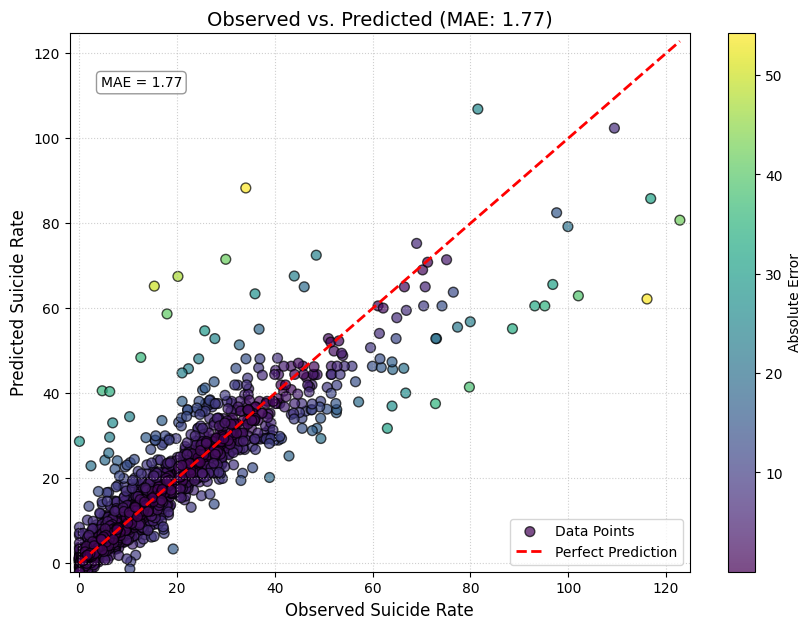

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the error for each point
error = np.abs(val_y - predict)
mae = 1.7684  # Your calculated MAE

plt.figure(figsize=(10, 7))

# 1. Scatter Plot: Color the points by the size of the error
# We use 'coolwarm' or 'viridis' to show intensity
scatter = plt.scatter(val_y, predict, c=error, cmap='viridis', 
                      alpha=0.7, edgecolors='k', s=50, label='Data Points')

# 2. Reference Line: The "Perfect Prediction" line (y = x)
line_min, line_max = val_y.min(), val_y.max()
plt.plot([line_min, line_max], [line_min, line_max], 
         color='red', linestyle='--', lw=2, label='Perfect Prediction')

# 3. Adjusting the Scale
# We set the padding so the points aren't hugging the edges
plt.xlim(line_min - 2, line_max + 2)
plt.ylim(line_min - 2, line_max + 2)

# 4. Labels and Visuals
plt.colorbar(scatter, label='Absolute Error')
plt.xlabel('Observed Suicide Rate', fontsize=12)
plt.ylabel('Predicted Suicide Rate', fontsize=12)
plt.title(f'Observed vs. Predicted (MAE: {mae:.2f})', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Annotation for clarity
plt.annotate(f'MAE = {mae:.2f}', xy=(0.05, 0.90), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.show()